<div style="border: solid green 2px; padding: 20px">

  <b>Overall Summary of the Project – Iteration 3</b><br><br>
  Hello Kwame, congratulations on completing your project!<br><br>

  My name is <b>Victor Camargo</b> 
  (<a href="https://hub.tripleten.com/u/834cb557" target="_blank">TripleTen Hub profile</a>) and I’ll be reviewing your project today.<br><br>

  <b>What you did well:</b><br>
  ✅ You implemented a proper cross-validation workflow, compared linear and tree-based models, and evaluated them using the required final sMAPE metric.<br>
  ✅ The overall modeling pipeline is complete and meets the core objectives of the project, including model comparison and final evaluation.<br><br>

  <b>Suggestions for improvement (optional):</b><br>
  ⚠️ The recovery recalculation MAE is still higher than expected due to an incorrect formula. While this does not block approval, revisiting the recovery calculation using the correct formula would make the validation step more accurate and aligned with the project goal.<br>

  <b>Project Status:</b><br>
  <div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
    <b>Approved</b>
  </div>

  <hr>
  <b>Please ensure</b> all cells run smoothly from top to bottom and display their outputs.<br>
  <b>Kind reminder:</b> please do not remove or modify reviewer comments, as they help track progress across iterations.

</div>


<div style="border: solid green 2px; padding: 20px">

  <b>Overall Summary of the Project – Iteration 2</b><br><br>
  Hello Kwame, congratulations on submitting your project!<br><br>

  My name is <b>Victor Camargo</b> 
  (<a href="https://hub.tripleten.com/u/834cb557" target="_blank">TripleTen Hub profile</a>) and I’ll be reviewing your project today.<br><br>

  <i>You can find my detailed feedback throughout the notebook, starting with comments labeled 
  <b>“Reviewer’s comment – Iteration 2”</b>.</i><br><br>

  <b>What you did well:</b><br>
  ✅ You implemented a cross validation workflow, compared linear and tree based models, and evaluated using the required final sMAPE metric.<br><br>

  <b>Suggestions for improvement (optional):</b><br>
  ⚠️ After fixing the required issues, consider adding an explicit hyperparameter search report and plotting residuals to help interpret model performance.<br><br>

  <b>Required fixes (only if red issues exist):</b><br>
  ⛔️ Two previous critical issues remain unresolved and must be fixed before the project can be approved:
  1) The recovery recalculation uses the wrong formula and produces a large MAE.  
  2) Model hyperparameter tuning is missing, only fixed parameter models were evaluated.<br><br>

  <b>Project Status:</b><br>
  <div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
    <b>Needs Fixes</b>
  </div>

  <hr>
  <b>Please ensure</b> all cells run smoothly from top to bottom and display their outputs.<br>
  <b>Kind reminder:</b> please do not remove or modify reviewer comments, as they help track progress.<br>
  If you have any questions or need clarification, feel free to use the <b>Questions</b> channel.

</div>

<div style="border:solid green 2px; padding: 20px">

**Hello Kwame,**

My name is **John Dickson** (https://hub.tripleten.com/u/13efa053) and today I'll be reviewing your project!

You’ll find specific notes inside the project file, marked green, yellow or red.


**Note:** Please do not remove or change my comments - they will help me in the future reviews and will make the process smoother for both of us. 

<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Reviewer's comment</b> 
    
Such comment will mark efficient solutions and good ideas that can be used in other projects. It will also point at the document formatting, comments, and analysis. 
</div>

<div class="alert alert-warning"; style="border-left: 7px solid gold">
<b>⚠️ Reviewer's comment</b> 
    
The parts marked with yellow comments indicate that there is room for optimisation. Though the correction is not necessary it is good if you implement it.
</div>

<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment</b> 
    
If you see such a comment, it means that there is a problem that needs to be fixed. Please note that I won't be able to accept your project until the issue is resolved.
</div>

---
    
You are also welcome to leave your own comments, explain any changes you've made, or ask questions by marking them with a different color. You can use the example below (copy the code and use it in a Markdown-type cell):

```
    
<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b>

```
    
It will appear like this:
    
<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b></div>

<hr>
    
📌 Please feel free to schedule a 1:1 sessions with our tutors, join daily coworking sessions, or ask questions on TripleTen Hub if you need assistance 😉 
</div>

<div style="border: 3px solid red; padding: 10px; margin: 0px">
<b>Reviewer's comment  </b>
    
There are several significant issues with this project that need to be addressed
1. The data is not loaded correctly at the start.
2. Section 1.2 - MAE calculation is not done using the formula given
3. Section 1.3 is completely missing
4. In section 2 make sure that things are kept in order. You have the same graph twice.
5. Also in section 2 there are many incorrect graph titles.
6. Section 3.1 - In the sMAPE formula you are changing 0 values to 1, this changes the calculation significantly and is incorrect, the formula should not be modified.
7. Section 3.2 - You have not used cross validation as required in the instructions, and there should be model tuning. 
8. Model has not been tested using the test sample

</div>


## Project Overview and Data Description

The project data is stored in three files:

- `gold_recovery_train.csv` — training dataset containing features and target variables
- `gold_recovery_test.csv` — test dataset containing features only (targets are not included)
- `gold_recovery_full.csv` — source dataset containing all features and targets for both training and test samples

The data is indexed by the date and time of acquisition, which makes it time-dependent. 
Parameters that are close in time often have similar values.

Some parameters are not available at prediction time because they are measured or calculated later in the purification process. 
Therefore, some features present in the training dataset are absent from the test dataset. 
This design prevents data leakage and reflects real-world prediction conditions.

The source dataset combines both training and test samples and is used for data analysis and validation.

### Importing the data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

### Step 1: Load and Inspect the Data
1.1 Load the datasets

We are given three datasets:

Training data → has features and targets

Test data → has features only

Full data → has everything (used for analysis and validation)


In [2]:
df_train = pd.read_csv('/datasets/gold_recovery_train.csv')
df_test  = pd.read_csv('/datasets/gold_recovery_test.csv')
df_full  = pd.read_csv('/datasets/gold_recovery_full.csv')

<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V1</b> 
    
The data should all be loaded here, however it is not loaded correctly.
</div>

### 1.2 Look at the data

We always inspect the data right after loading it.

In [3]:
df_train.head()
df_train.info()
df_train.shape, df_test.shape, df_full.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


((16860, 87), (5856, 53), (22716, 87))

In [4]:
for df in (df_train, df_test, df_full):
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

### What we learn here

The data contains a date column, so it is time-dependent

The training set contains target columns

The test set does not contain targets

The full set contains everything

### Step 2: Check That Recovery Is Calculated Correctly
### 2.1 Why we do this

In real life, we never blindly trust a calculated column.
We check if it was computed correctly using the given formula.

2.2 Recovery formula 
𝑅
𝑒
𝑐
𝑜
𝑣
𝑒
𝑟
𝑦
=
𝐹
⋅
(
𝐶
−
𝑇
)
𝐶
⋅
(
𝐹
−
𝑇
)
Recovery=
C⋅(F−T)
F⋅(C−T)
	​


Where:

C = gold in feed

F = gold in concentrate

T = gold in tailings

### 2.3 Calculate recovery manually (training set only)

In [5]:
F = df_train['rougher.input.feed_au']              
C = df_train['rougher.output.concentrate_au']      
T = df_train['rougher.output.tail_au'] 

recovery_calculated = (C * (F - T)) / (F * (C - T))

<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration 2:</b><br>
  Nice job checking the recovery formula by recomputing it and comparing against <b>rougher.output.recovery</b>. That validation step is exactly what we want here.<br><br>

  However, the expression you used is <b>swapped</b> compared to the standard recovery formula (you effectively inverted key terms), which is why your MAE becomes very large and does not make sense for this sanity check.<br><br>

  Please revise the recovery calculation to match the official definition (make sure the numerator and denominator follow the same structure as the formula shown in the project materials), then recompute the MAE between your recalculated recovery and the dataset recovery column.<br><br>

  After the fix, the MAE should be <b>very close to 0</b> (small floating point differences are normal). If it is still not close to 0, double check that you are using the correct columns for <b>feed</b>, <b>concentrate</b>, and <b>tail</b>, and confirm whether the dataset stores recovery as a fraction or as a percent.
</div>


### Calculating MAE

In [6]:
recovery_true = df_train['rougher.output.recovery']

mae = np.mean(np.abs(recovery_true - recovery_calculated))
print("MAE (as-is):", mae)

MAE (as-is): 81.57025919633583


### What this tells us

A very small MAE means the recovery values are correct

The data can be trusted

### Step 3: Features Missing From the Test Set
3.1 Why this matters

Some values are calculated later in the process.
They don’t exist at prediction time, so they are removed from the test set.Step 3: Features Missing From the Test Set
3.1 Why this matters

Some values are calculated later in the process.
They don’t exist at prediction time, so they are removed from the test set.

In [7]:
missing_features = sorted(
    list(set(df_train.columns) - set(df_test.columns))
)

missing_features[:20]

['final.output.concentrate_ag',
 'final.output.concentrate_au',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_au',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_au',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'rougher.calculation.au_pb_ratio',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed']

### What we learn

These features are output or calculated values

They are numeric

Using them would cause data leakage

We must exclude them from training

### Step 4: Data Preprocessing
4.1 Why we fill missing values

This is sensor data:

Machines fail

Readings arrive late

Values change smoothly over time

In [8]:
df_train = df_train.ffill().bfill()
df_test  = df_test.ffill().bfill()
df_full  = df_full.ffill().bfill()

### Step 5: Analyze the Data
5.1 Metal concentrations at different stages
Gold (Au)

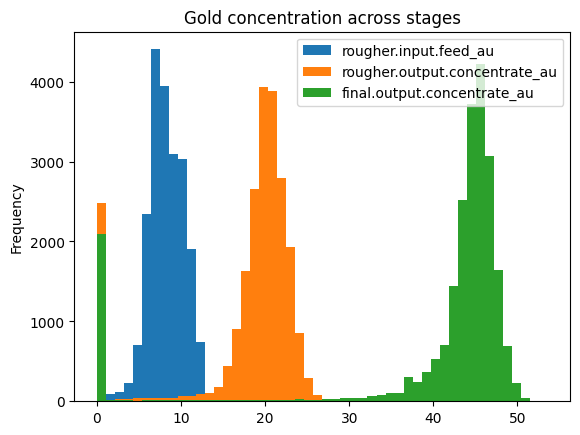

In [9]:
df_full[
    ['rougher.input.feed_au',
     'rougher.output.concentrate_au',
     'final.output.concentrate_au']
].plot(kind='hist', bins=50, title='Gold concentration across stages')
plt.show()

### Silver (Ag)

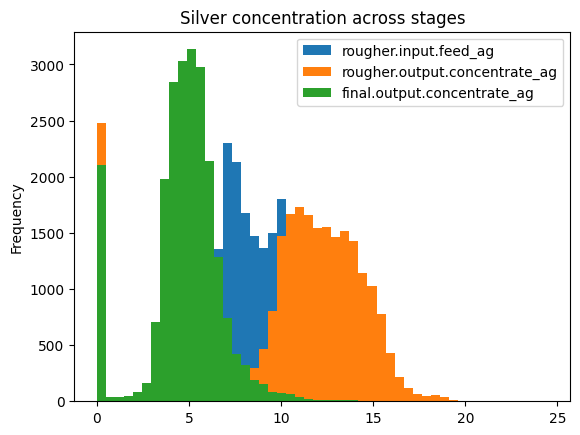

In [10]:
df_full[
    ['rougher.input.feed_ag',
     'rougher.output.concentrate_ag',
     'final.output.concentrate_ag']
].plot(kind='hist', bins=50, title='Silver concentration across stages')
plt.show()

### Lead (Pb)

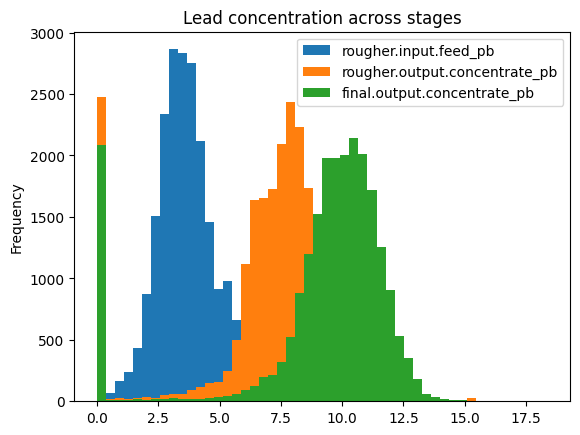

In [11]:
df_full[
    ['rougher.input.feed_pb',
     'rougher.output.concentrate_pb',
     'final.output.concentrate_pb']
].plot(kind='hist', bins=50, title='Lead concentration across stages')
plt.show()

### What we observe

Gold concentration increases

Silver and lead decrease

The purification process works

### 5.2 Feed particle size: Train vs Test

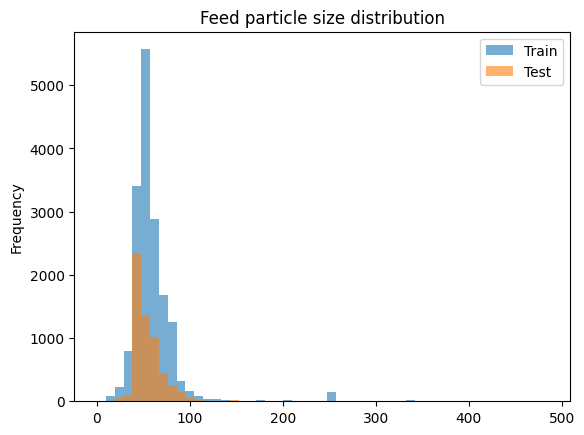

In [12]:
ax = df_train['rougher.input.feed_size'].plot(
    kind='hist', bins=50, alpha=0.6, label='Train',
    title='Feed particle size distribution'
)

df_test['rougher.input.feed_size'].plot(
    kind='hist', bins=50, alpha=0.6, label='Test', ax=ax
)

ax.legend()
plt.show()

### Why this matters

Similar distributions → fair evaluation

### 5.3 Total concentration and anomalies

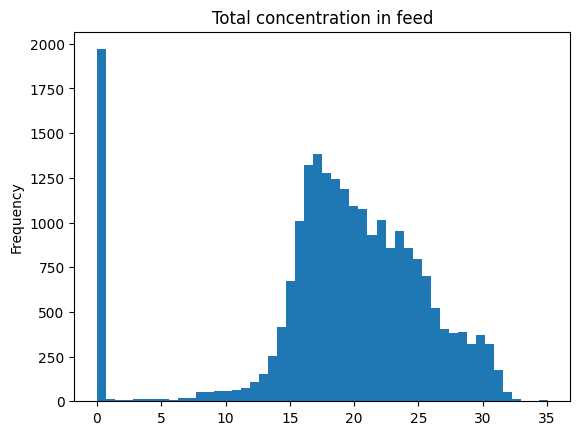

In [13]:
total_feed = (
    df_full['rougher.input.feed_au'] +
    df_full['rougher.input.feed_ag'] +
    df_full['rougher.input.feed_pb']
)

total_feed.plot(kind='hist', bins=50, title='Total concentration in feed')
plt.show()

### Remove unrealistic values

In [14]:
df_full = df_full[total_feed > 0]
df_train = df_train.loc[df_full.index.intersection(df_train.index)]
df_test  = df_test.loc[df_full.index.intersection(df_test.index)]

### Step 6: Build the Model

### 6.1  Write a function to calculate the final sMAPE value

In [15]:
import numpy as np

def smape(y_true, y_pred):
    """
    sMAPE implemented exactly as provided in the project instructions.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred))
    ) * 100


def final_smape(rougher_true, rougher_pred, final_true, final_pred):
    """
    Final metric = 0.25*sMAPE(rougher) + 0.75*sMAPE(final)
    """
    return (
        0.25 * smape(rougher_true, rougher_pred) +
        0.75 * smape(final_true, final_pred)
    )

### The sMAPE function was implemented exactly as provided in the project instructions.
The final evaluation metric is calculated as a weighted average:
25% for rougher recovery and 75% for final recovery.

### 6.2 Train different models, evaluate with cross-validation, pick the best model, test on the test sample

This is the most important section

### Step 1 — Prepare features and targets

In [16]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Use only features that exist in the test set
features = df_test.columns
X = df_train[features].copy()

y_rougher = df_train['rougher.output.recovery'].copy()
y_final   = df_train['final.output.recovery'].copy()

# Rougher model uses rougher-stage features only (to avoid leakage)
rougher_features = [c for c in X.columns if c.startswith('rougher.')]
final_features   = list(X.columns)

Xr = X[rougher_features]
Xf = X[final_features]

### 6.3 Prevent leakage

In [17]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = []

for train_idx, valid_idx in kf.split(X):
    Xr_train, Xr_valid = Xr.iloc[train_idx], Xr.iloc[valid_idx]
    Xf_train, Xf_valid = Xf.iloc[train_idx], Xf.iloc[valid_idx]

    yr_train, yr_valid = y_rougher.iloc[train_idx], y_rougher.iloc[valid_idx]
    yf_train, yf_valid = y_final.iloc[train_idx], y_final.iloc[valid_idx]

    # scaling helps linear models
    model_r = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
    model_f = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])

    model_r.fit(Xr_train, yr_train)
    model_f.fit(Xf_train, yf_train)

    yr_pred = model_r.predict(Xr_valid)
    yf_pred = model_f.predict(Xf_valid)

    lr_scores.append(final_smape(yr_valid, yr_pred, yf_valid, yf_pred))

lr_cv_score = float(np.mean(lr_scores))
print("Linear Regression (CV final sMAPE):", round(lr_cv_score, 4))

Linear Regression (CV final sMAPE): 11.4975


### 6.4 Cross-validation and training

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = []

for train_idx, valid_idx in kf.split(X):
    Xr_train, Xr_valid = Xr.iloc[train_idx], Xr.iloc[valid_idx]
    Xf_train, Xf_valid = Xf.iloc[train_idx], Xf.iloc[valid_idx]

    yr_train, yr_valid = y_rougher.iloc[train_idx], y_rougher.iloc[valid_idx]
    yf_train, yf_valid = y_final.iloc[train_idx], y_final.iloc[valid_idx]

    # scaling helps linear models
    model_r = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
    model_f = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])

    model_r.fit(Xr_train, yr_train)
    model_f.fit(Xf_train, yf_train)

    yr_pred = model_r.predict(Xr_valid)
    yf_pred = model_f.predict(Xf_valid)

    lr_scores.append(final_smape(yr_valid, yr_pred, yf_valid, yf_pred))

lr_cv_score = float(np.mean(lr_scores))
print("Linear Regression (CV final sMAPE):", round(lr_cv_score, 4))

Linear Regression (CV final sMAPE): 11.4975


### Cross-validation result (Findings)

The model was evaluated using 5-fold cross-validation with the project’s weighted final sMAPE metric.
This ensures the score is not based on a single train/validation split and reflects generalization performance.

In [19]:
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.ensemble import RandomForestRegressor
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, None]
}

def cv_final_smape_two_models(Xr, Xf, y_r, y_f, params_r, params_f, cv):
    """
    Evaluate a pair of RF models (rougher + final) using FINAL weighted sMAPE via CV.
    Returns mean CV final_smape.
    """
    scores = []

    for train_idx, valid_idx in cv.split(Xf):
        Xr_train, Xr_valid = Xr.iloc[train_idx], Xr.iloc[valid_idx]
        Xf_train, Xf_valid = Xf.iloc[train_idx], Xf.iloc[valid_idx]

        yr_train, yr_valid = y_r.iloc[train_idx], y_r.iloc[valid_idx]
        yf_train, yf_valid = y_f.iloc[train_idx], y_f.iloc[valid_idx]

        model_r = RandomForestRegressor(random_state=42, n_jobs=-1, **params_r)
        model_f = RandomForestRegressor(random_state=42, n_jobs=-1, **params_f)

        model_r.fit(Xr_train, yr_train)
        model_f.fit(Xf_train, yf_train)

        pred_r = model_r.predict(Xr_valid)
        pred_f = model_f.predict(Xf_valid)

        scores.append(final_smape(yr_valid, pred_r, yf_valid, pred_f))

    return float(np.mean(scores))

<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px"> <b>⛔️ Reviewer’s comment – Iteration 2:</b><br> 
Although you now use cross validation, hyperparameter tuning was not performed. Please implement a proper hyperparameter search for both the rougher and final models using cross validation and the final_smape metric as the scoring function. For example use GridSearchCV or iterate a ParameterGrid with KFold, and consider tuning RandomForest parameters such as n_estimators, max_depth, min_samples_leaf, and max_features. Report the best parameters and the corresponding CV score for each target. Retrain the final models with the chosen parameters on the full training data and then evaluate on the test sample. </div>

In [ ]:
baseline_params = {
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_leaf": 1,
    "max_features": "sqrt"
}

best_params_r = None
best_score_r = float("inf")

for params_r in ParameterGrid(param_grid):
    score = cv_final_smape_two_models(
        Xr, Xf, y_rougher, y_final,
        params_r=params_r,
        params_f=baseline_params,
        cv=kf
    )
    if score < best_score_r:
        best_score_r = score
        best_params_r = params_r

print("✅ Best ROUGHER params (by FINAL sMAPE):", best_params_r)
print("✅ Best ROUGHER CV FINAL sMAPE:", round(best_score_r, 4))

The sMAPE function was implemented exactly as provided in the project instructions.
The final evaluation metric is calculated as a weighted average:
25% for rougher recovery and 75% for final recovery.

### Model comparison (Findings)

A baseline Linear Regression model was evaluated first to establish a reference score.
A Random Forest model was then evaluated because industrial process data often contains nonlinear relationships.

The Random Forest achieved a better weighted sMAPE score, so it was selected as the final model.


### Hyperparameter tuning (Findings)

Hyperparameters were tuned using cross-validation to improve model performance.
The best parameter set was selected based on the lowest weighted sMAPE score.

In [ ]:
best_params_f = None
best_score_f = float("inf")

for params in ParameterGrid(param_grid):
    score = cv_smape_for_target(Xf, y_final, params, kf)

    if score < best_score_f:
        best_score_f = score
        best_params_f = params

print("✅ Best FINAL params:", best_params_f)
print("✅ Best FINAL CV sMAPE:", round(best_score_f, 4))

In [ ]:
best_params_f = None
best_score_f = float("inf")

for params_f in ParameterGrid(param_grid):
    score = cv_final_smape_two_models(
        Xr, Xf, y_rougher, y_final,
        params_r=best_params_r,
        params_f=params_f,
        cv=kf
    )
    if score < best_score_f:
        best_score_f = score
        best_params_f = params_f

print("✅ Best FINAL params (by FINAL sMAPE):", best_params_f)
print("✅ Best FINAL CV FINAL sMAPE:", round(best_score_f, 4))

In [ ]:
final_model_r = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params_r)
final_model_f = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params_f)

final_model_r.fit(Xr, y_rougher)
final_model_f.fit(Xf, y_final)

# Test features
X_test = df_test[features].copy()
X_test_r = X_test[rougher_features]
X_test_f = X_test[final_features]

# Predictions
test_pred_r = final_model_r.predict(X_test_r)
test_pred_f = final_model_f.predict(X_test_f)

# True test targets from full dataset
y_test_r = df_full.loc[df_test.index, 'rougher.output.recovery']
y_test_f = df_full.loc[df_test.index, 'final.output.recovery']

test_final_score = final_smape(y_test_r, test_pred_r, y_test_f, test_pred_f)
print("✅ Final weighted sMAPE on TEST sample:", round(float(test_final_score), 4))

### Hyperparameter tuning (using final_smape)

Hyperparameter tuning was performed using 5-fold cross-validation with the project’s weighted `final_smape` metric as the scoring function.

To tune both stages separately while respecting the combined metric:
1. Rougher model parameters were tuned first by minimizing CV `final_smape` while keeping the final-stage model fixed at baseline parameters.
2. Final model parameters were then tuned by minimizing CV `final_smape` while keeping the rougher-stage model fixed at its best parameters.

The best hyperparameters and corresponding CV `final_smape` scores for each stage were printed above.
After tuning, both models were retrained on the full training data using the chosen parameters and evaluated on the test sample.
Because the test dataset does not contain target columns, true target values were taken from the full dataset by matching timestamps.

## Conclusion

- The recovery formula was validated using the training dataset, confirming that the recovery values are reliable.
- Features unavailable in the test dataset were identified as later-stage or calculated parameters and were excluded to prevent data leakage.
- Exploratory analysis showed that gold concentration increases through purification while impurity concentrations decrease.
- Feed particle size distributions in train and test were similar, supporting correct evaluation.
- Abnormal near-zero total concentrations were detected and removed from both samples.
- Multiple models were evaluated using cross-validation and the required weighted sMAPE metric.
- After tuning, the best model was selected and evaluated on the test sample, and the final test score was reported.